<center>

# Surface Defect Classification
</center>




<br>

----

<br>



## Description

Surface defect classification is a critical task in various industries, including manufacturing, quality control, and materials science. The goal is to identify and categorize defects on surfaces of manufactured products, which can range from functional to aesthetic issues. Accurate classification of surface defects is essential for ensuring product quality, reducing waste, and improving overall efficiency in production processes. Misclassification can lead to increased costs as rework or scrapping may be necessary. Additionally, customer dissatisfaction can lead to warranty claims, returns, and damage to the brand's reputation [1]. The consequences of inaccurate classification can extend beyond cosmetic, productivity, or reputation issues. In many industries, such as in automotive or aerospace, surface defects mean failure precursors that can lead to catastrophic consequences. For instance, micro-cracks in metal can lead to fatigue failure or delamination in composite materials which can end in structural failure [2]. Therefore, accurate classification of surface defects plays a vital role for ensuring the safety and long-term reliability of products in these industries.

In the past, methods relied on local features and handcrafted algorithms, such as structural edge, skeleton, or template matching. Thresholding approaches were also widely used, including iterative optimal thresholding as Otsu’s and Kittler’s techniques. However, these methods often become labor-intensive and may fail to achieve the required level of accuracy in complex industrial environments [3]. In recent years, Machine Learning (ML) has become increasingly adopted in industrial inspection tasks due to its ability to learn complex patterns and representative features directly from data, resulting in improved accuracy and efficiency [1]. Surface defect classification/detection has become one of the most important application areas of ML, as almost every manufacturing product has a visible of functional surface that has to meet certain quality standards.

Despite the significant advances achieved with classical ML techniques such as Neural Networks (NNs), they show room for improvement in performance. In the quest for reaching superior performance, exploring alternative approaches, such as Quantum Machine Learning (QML), is gaining more and more popularity.
QML aims to leverage the principles of quantum mechanics to enhance the capabilities of traditional ML algorithms. One such approach is the use of Quantum Boltzmann Machines (QBMs), which are the quantum analogs of classical Boltzmann Machines (BMs). QBMs can learn complex probability distributions, sometimes more efficiently than their classical counterparts, and, when paired with Quantum Annealing (QA), they can perform the sampling process required for training and inference potentially faster than classical methods [4]. We pair this promising approach with a concept that has helped classical NNs to achieve state-of-the-art performance in image classification tasks: convolution. Convolutional Deep Quantum Boltzmann Machines (CDQBMs) are a variant of QBMs that incorporate convolutional layers, allowing them to capture spatial hierarchies and local features in data, which is particularly beneficial for image classification tasks as required by this use case.

For this showcase, we will explore the application of this QML-approach for surface defects of hot-rolled steel strips. The Northeastern University (NEU) surface defect database will give as the necessary data to learn how to distinguish between pits and rust on 64x64 grayscale images. We will compare the performance of the CDQBM with a classical Convolutional Neural Network (CNN) to evaluate the potential advantages of the quantum approach in this context.


## Background


Before we dive into the implementation details, a brief overview of the key concepts will help explain the following workflow. Here we will focus on the basics of Boltzmann Machines and Quantum Annealing. Please refer to our educational platform for further fundamental concepts of Quantum Machine Learning and Quantum Computing.

### (Deep) Boltzmann Machines


Boltzmann Machines (BMs)  are undirected stochastic neural networks composed of $n$ units, which can be grouped into $n_v$ visible units $v$ and (optionally) $n_h$ hidden units $h$.
For supervised discriminative learning, the visible units $v$ include both the input features and the label. The input units are fixed to the observed data (e.g., pixel intensities) during training. Since they are always clamped, they do nothing more than providing biases to the rest of the units within the system (see $b^{\text{eff}}_i$). The hidden units are used to capture complex correlations in the input, capturing higher-order features. Consequently, the label units are used to read out the predicted class after the sampling process.
 These units, hidden and label units, can take on the values 0 or 1 and switch between these states with a certain probability. The probability of finding the system in a certain configuration is determined by the energy function of the system:

$$E(v, h) = -\sum_{i} b^{\text{eff}}_i s_i - \sum_{\substack{i,j\\i<j}} W_{i,j}s_is_j$$

with

$$b^{\text{eff}}_i = b_i + \sum_{k} W_{i,k}x_k.$$

Here, $s$ represents the state of hidden and label units, $b_i$ are the biases, and $W_{i,j}$ are the weights between units. Together, they define the energy of the system’s current configuration. Configurations with lower energy are more probable than those with higher energy, with their distribution governed by the well-known Boltzmann distribution. The connectivity can be limited to layers of hidden units to form a Deep Boltzmann machine (DBM).


Now, only the first layer of hidden units is directly connected to the input units, while the subsequent layers are only connected to the previous layer of hidden units.
 With this multilayer structure, the concept of hierarchy can be introduced, allowing the model to learn layers of increasingly abstract features in latent space.
 Additionally, we introduce the concept of convolution to the DBM. Weight sharing and local connectivity are the key features of convolutional layers, which allow the model to capture spatial hierarchies and local features in data. We combine this with deterministic max pooling layers to further enhance the model's ability to capture spatial hierarchies and reduce the dimensionality of the feature maps.
  This is particularly beneficial for image classification tasks, as it enables the model to learn patterns that are invariant to translation and other transformations. By applying convolutional layers and hierarchical feature learning to the BM, we can create a Convolutional Deep Boltzmann Machine (CDBM) that is well-suited for image classification tasks, such as surface defect classification.
 The image below shows the structure of such a CDBM.

<center>

<img src="notebook_src/images/figure_cdqbm.png" width="700">

</center>

The model introduced above is capable of capturing complex distributions of local and hierarchical features, as well as their relationship to the label. But how exactly is this achieved?

Training a BM aims to adjust the weights and biases so that the model reproduces the dependencies observed in the training data for a given input. This means that when certain features are strongly associated with a particular label in the training set, the BM’s sampling distribution should reproduce that same distribution. BMs are therefore universal approximators of probability distributions. For this purpose the training process of supervised BMs consists of two separate phases: the clamped (also called positive) and the unclamped (negative) phase. In the clamped phase, the label units are additionally clamped to the true label of the current data point. In the unclamped phase the label units are set to evolve freely, while the input units still remain clamped. The difference between the average configuration of these two phases is then used to determine the weight updates.


### Quantum Annealing and Quantum Boltzmann Machines

Training and inference in BMs requires generating samples from the Boltzmann distribution, which is commonly accomplished through stochastic sampling methods, including Markov Chain Monte Carlo techniques. However, these methods with current classical hardware can be slow especially for large fully connected BMs, which is why this type of ML-model has been deemed impractical for many real-world applications in the past.

Quantum Annealing (QA) is a highly promising alternative approach for the sampling process. This quantum algorithm is designed to find minimum energy states of systems using effects such as quantum tunneling and superposition. Through these quantum phenomena, QA can potentially explore the energy landscape more efficiently than classical methods, especially in complex and high-dimensional spaces. The resulting sampling distribution, however, does not always exactly follow the Boltzmann distribution. This can be traced back to various factors, such as the physical temperature of the hardware, the freeze-out effect, and overall noise. To mitigate these effects, the parameters of the BM can be rescaled using an effective temperature parameter $\beta_{\text{eff}}$. Nonetheless, studies have shown that though the sample distribution may deviate from the true Boltzmann distribution, it can still be effectively used for training and inference in BMs as if it was the true distribution [5]. Therefore, in this notebook, we will simply set $\beta_{\text{eff}}$ to 1.0 and, thus, skip this rescaling step.

With this framework, QA-based Quantum Boltzmann Machines (QBMs) leverage the capabilities of this algorithm to perform the sampling process required for training and inference potentially more efficiently than classical methods. The model, however, remains the same as in classical BMs.


## Setup & Imports




In [1]:
from src.model.cdqbm_state import Conv_Deep_QBM
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from PIL import Image
import notebook_utils as utils
from src.model import geometry as geom
from src.model.inference import InferenceContext
from src.model.layers import pooled_indices_for_input
import minorminer
import networkx as nx
from src.train.train import getting_samples_batch, get_average_configuration_batch, get_error, normalize_error, apply_gradient_step

SEED = 42

example_model = Conv_Deep_QBM(seed=SEED) #TODO: make Default values specifically for the notebook

bias: [0.50238133]


Given the limited availability of quantum hardware, the use of actual QA-devices lies beyond the scope of this notebook. Instead, Simulated Annealing (SA) will serve as a classical approximation of our sampling process, as it, similarly as QA, also returns samples from an approximate Boltzmann distribution. This allows us to demonstrate the training and inference process of a CDQBM without requiring access to quantum hardware. However, it is important to note that SA is a classical algorithm and does not capture the quantum effects that QA does, which may lead to differences in performance and results compared to using actual QA hardware. Nonetheless, the actual workflow remains the same.

## Dataset Preparation

In order to appropriately train and evaluate our model, we first need to prepare our dataset. Many QML approaches suffer from the limitation that they require some kind of classical preprocessing of the data, as the dimensionality of the input data has to fit the encoding scheme for the quantum hardware. For instance, several approaches rely on the input dimensionality to equal the number of qubits of their encoding scheme like angle or amplitude encoding. However, current quantum hardware is limited in the number of available qubits, which often necessitates in prior feature extraction techniques like principal component analysis to reduce the dimensionality of the input data. As a result, losing much of the original feature space in the process.

In contrast, the discriminative architecture incorporates local receptive fields into the effective bias of the convolutional nodes, allowing the input data to be fed directly into the model, provided that the hardware supports a sufficient number of such nodes. Notably, quantum annealing (QA) hardware offers significantly more qubits than current gate-based quantum computers (e.g., D-Wave Advantage2 provides 5,000+ qubits, compared to ~100–1,000 qubits for state-of-the-art gate-based devices). This enables us to retain a large portion of the original feature space. Given that the original NEU classification dataset consists of 64×64 pixel images, a direct implementation would in principle be possible using appropriate pooling size. However, this would significantly limit the number of convolutional filters. Instead, we downsample the images to 28×28 pixels using the Python Imaging Library's LANCZOS interpolation method and increase the contrast by a factor of 1.5 to compensate for the loss of information. This approach preserves much of the original feature space while ensuring compatibility with both the model and hardware constraints, without requiring explicit feature extraction techniques.

Using classes: ['gg', 'rp']


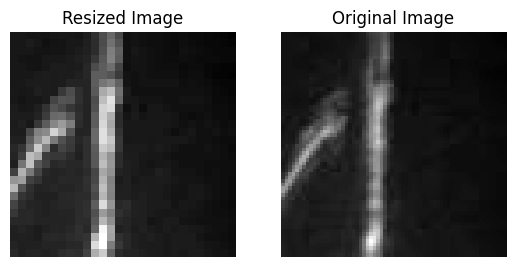

In [2]:
classes = ['gg', 'rp']
train_test_val_split = [0.7, 0.15, 0.15]
contrast_factor = 1.5

imgs, labels = utils.load_neu_cls_images(classes=classes)
unprocessed_sample_image = imgs[0]
x, y = [], []


for img, l in zip(imgs, labels) :
        im = Image.fromarray(img)
        im = im.convert('L')
        im = im.resize((28,28), Image.Resampling.LANCZOS)

        from PIL import ImageEnhance
        enhancer = ImageEnhance.Contrast(im)
        im = enhancer.enhance(contrast_factor)

        arr = np.asarray(im) / 255.0
        x.append(arr)
        y.append(l)

x = np.stack(x).astype(np.float32)
y = np.array(y, dtype=np.uint8)

#show original sample and resized sample
import matplotlib.pyplot as plt

plt.subplot(1, 2, 2)
plt.imshow(unprocessed_sample_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

plt.subplot(1, 2, 1)
plt.imshow(x[0], cmap='gray')
plt.title('Resized Image')
plt.axis('off')

# split into train, test, val
X_temp, X_test, y_temp, y_test = train_test_split(x, y, test_size=train_test_val_split[2], random_state=SEED, shuffle=True)
relative_val_size = train_test_val_split[1] / (train_test_val_split[0] + train_test_val_split[1])
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=relative_val_size, random_state=SEED, shuffle=True)

## Quantum Data Encoding

Once that the dataset has been prepared, the data must be encoded in a form compatible with the requirements of QA hardware. This is achieved by expressing the model as a Quadratic Unconstrained Binary Optimization (QUBO) problem. For this purpose we first need to process the image with our convolutional units and pool the ones that have the highest activation. Afterwards, we only proceed with the pooled units when building the QUBO. The bias will include the model bias parameters and the input data for convolutional nodes, while the coupler weights will be adjusted to the model weights. The resulting QUBO problem can then be solved using QA or, in our case, SA to obtain samples from the Boltzmann distribution defined by the model.


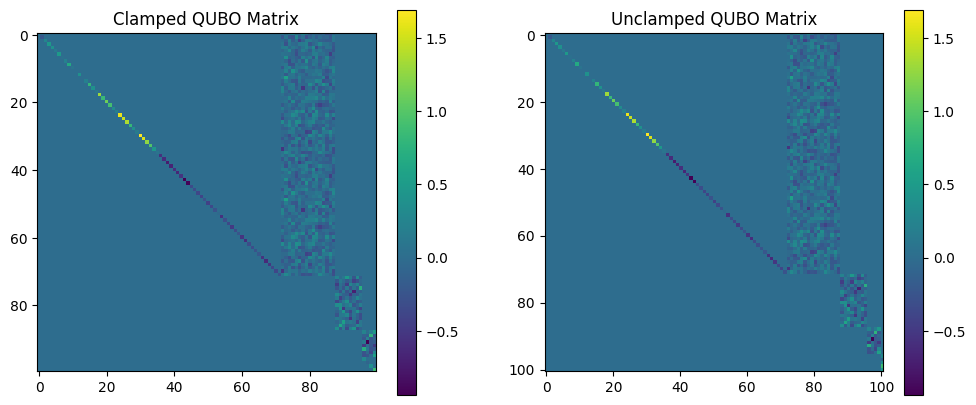

In [5]:
def prepare_context(model: Conv_Deep_QBM, x_img) -> InferenceContext:
    fmap_2d = []
    fmap_flat = []
    pooled_idexes = []

    for fk in range(model.num_filter_kernels):
        currentlayer_fmap_2d = geom.conv2d_valid_stride(x_img, model.kernel_weights[fk], model.stride)
        currentlayer_fmap_flat = currentlayer_fmap_2d.ravel()
        fmap_2d.append(currentlayer_fmap_2d)
        fmap_flat.append(currentlayer_fmap_flat)

        if model.pooling_type == 'deterministic':
            pooled_idx = pooled_indices_for_input(
                fmap_flat=currentlayer_fmap_flat,
                num_conv_units=model.num_conv_units,
                pooling_type=model.pooling_type,
                pool_windows=getattr(model, "pool_windows", []),
            )

            pooled_idexes.append(pooled_idx)


    return InferenceContext(
        fmap_2d=fmap_2d,
        fmap_flat=fmap_flat,
        pooled_idx=pooled_idexes
    )




def _conv_linear_terms(model, ctx) -> np.ndarray:
    """Return linear biases for the conv_sl block"""
    bases = []
    for fk in range(model.num_filter_kernels):
        base = ctx.fmap_flat[fk][ctx.pooled_idx[fk]]
        base = base + model.biases_conv_units[fk][0]
        bases.append(base)

    return np.array(bases)



def add_conv_biases(model, Q, ctx):
    if model.kernel_size > 0:
        conv_biases = _conv_linear_terms(model, ctx)
        for fk in range(model.num_filter_kernels):
            conv_bias = conv_biases[fk]
            conv_bias = np.diag(conv_bias)
            Q[model.slices.conv[fk], model.slices.conv[fk]] += conv_bias
    else:
        Q[model.slices.seq_layers[0][0], model.slices.seq_layers[0][0]] += np.diag(ctx.fmap_flat)

    return Q


def add_seq_weights(model, Q):
    if model.kernel_size > 0:
        first_seq_sl = model.slices.seq_layers[0][0]
        for fk in range(model.num_filter_kernels):
            pool_sl = model.slices.pool[fk]
            W = model.weights_sequential_layer[0][fk]
            Q[pool_sl, first_seq_sl] += W

        for i, cur_sl in enumerate(model.slices.seq_layers[0][1:]):
            prev_sl = model.slices.seq_layers[0][i]
            W = model.weights_sequential_layer[1][i]
            Q[prev_sl, cur_sl] += W
    else:
        for i, cur_sl in enumerate(model.slices.seq_layers[0][:-1]):
            next_sl = model.slices.seq_layers[0][i+1]
            W = model.weights_sequential_layer[0][i]
            Q[cur_sl, next_sl] += W

    # within-layer
    if not model.is_restricted:
        for li, cur_sl in enumerate(model.slices.seq_layers[0]):
            Q[cur_sl, cur_sl] += np.triu(model.weights_intralayer_sequential[0][li], k=1)

    return Q


def add_seq_biases(model, Q):
    for l, seq_layer in enumerate(model.slices.seq_layers):
        for s, sl in enumerate(seq_layer):
            Q[sl, sl] += np.diag(model.biases_sequential_units[l][s])

    return Q


def add_weights_hidden_to_output(model: Conv_Deep_QBM, Q):
    for idx, last_sl in enumerate(model.slices.last_hidden):
        W_hy = model.weights_hidden_to_output[idx]
        Q[last_sl, model.slices.out] += W_hy
    return Q




def build_clamped_qubo(model, ctx, label_vec: np.ndarray, beta_eff: float, do_conv_label_bias=False) -> np.ndarray:
    n = model.spec.n_hidden
    Q = np.zeros((n, n), dtype=float)

    # Conv
    Q = add_conv_biases(model, Q, ctx)

    # Sequential
    if len(model.sequential_layer_sizes) > 0:
        Q = add_seq_weights(model, Q)

        Q = add_seq_biases(model, Q)

    # label bias
    for idx, last_sl in enumerate(model.slices.last_hidden):
        eff = (model.weights_hidden_to_output[idx] @ label_vec.reshape(-1, 1)).reshape(-1)
        Q[last_sl, last_sl] += np.diag(eff)

    # conncet label

    if do_conv_label_bias:
        for idx, conv_sl in enumerate(model.slices.conv):
            conv_label_bias = (model.conv_label_bias[idx] @ label_vec.reshape(-1, 1)).reshape(-1)
            Q[conv_sl, conv_sl] += np.diag(conv_label_bias)

    return Q / float(beta_eff)



def build_unclamped_qubo(model: Conv_Deep_QBM, ctx, beta_eff: float, do_conv_label_bias=False) -> np.ndarray:
    n = model.spec.n_hidden + model.spec.n_out
    Q = np.zeros((n, n), dtype=float)

    # Conv
    Q = add_conv_biases(model, Q, ctx)

    # Sequential
    if len(model.sequential_layer_sizes) > 0:
        Q = add_seq_weights(model, Q)
        # Hidden biases sequential
        Q = add_seq_biases(model, Q)

    # Hidden -> Output
    Q = add_weights_hidden_to_output(model, Q)

    # output
    Q[model.slices.out, model.slices.out] += np.triu(model.weights_output_output, k=1)
    Q[model.slices.out, model.slices.out] += np.diag(model.biases_output)

    if do_conv_label_bias:
        for idx, conv_sl in enumerate(model.slices.conv):
            conv_label_bias = model.conv_label_bias[idx]
            Q[conv_sl, model.slices.out] += conv_label_bias

    return Q / float(beta_eff)

# Example of building the QUBO for a single data point
inference_context = prepare_context(example_model, X_train[0])
clamped_Q = build_clamped_qubo(example_model, inference_context, y_train[0], beta_eff=1.0)
unclamped_Q = build_unclamped_qubo(example_model, inference_context, beta_eff=1.0, do_conv_label_bias=True)

# show the clamped and unclamped QUBO matrices
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(clamped_Q, cmap='viridis')
plt.title('Clamped QUBO Matrix')
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(unclamped_Q, cmap='viridis')
plt.title('Unclamped QUBO Matrix')
plt.colorbar()
plt.show()


## Quantum Model Design

Before our model can be deployed, we need to determine which physical qubits and couplers will represent our variables and connections in our QUBO problem. This process is called embedding and is a crucial step in utilizing QA-hardware. The embedding process involves mapping the logical variables of our model (e.g., the hidden units and label units) to the physical qubits on the quantum annealer. This mapping must also account for the connectivity constraints of the hardware, as not all qubits may be directly connected to each other. The goal is to find an embedding that minimizes the number of physical qubits used while still accurately representing the logical structure of our model. This often involves techniques such as minor embedding, where logical variables are represented by chains of physical qubits, and the use of auxiliary qubits to enforce constraints. The quality of the embedding can significantly impact the performance of the quantum annealer, as it affects both the accuracy of the solution and the time required for annealing.

For SA, the QUBO formulation of our model is already sufficient.



In [4]:
def find_embedding_with_client(bqm, solver_backend, seed):
    if bqm.quadratic == {}:
        qubo_graph = nx.Graph([(0, 0)])
        target_edges = qubo_graph.edges
    else:
        target_edges = list(bqm.quadratic.keys())
    embedding, embedding_found = minorminer.find_embedding(target_edges,
                                                           solver_backend.edges,
                                                           return_overlap=True,
                                                           random_seed=seed,
                                                           threads=4)
    while not embedding_found:
        print("No embedding found. Trying again...")
        embedding, embedding_found = minorminer.find_embedding(
            target_edges, solver_backend.edges, return_overlap=True
        )

        return embedding


SyntaxError: invalid syntax (1595611963.py, line 20)

The resulting embedding for our clamped model with 5 filters of size 5x5 and a single sequential layer with 4 units is shown in the image below. The topology shown is the Zephyr graph, which is used D-Wave's Advantage2 system. The different colors represent different logical variables, while the nodes represent physical qubits. The connections between the nodes represent the couplers on the hardware that allow for interactions between the qubits. Some of the connections and qubits can not be seen directly as this is a planar representation of the graph, but they are still present in the actual hardware.


<center>

<img src="notebook_src/images/embedding_clamped_Advantage2_system1.12.png" width="500">

</center>

## Post-Processing

After samples can now be obtained by a sampler of our choice, we need to process these to apply the gradient steps necessary for training. This involves calculating the average configuration of the clamped and unclamped phases and using the difference between these two configurations to determine the weight updates for our model:


$$
\delta b_i = \eta \bigl(\langle s_i\rangle_{clamped} - \langle s_i\rangle_{unclamped}\bigr),
$$

$$
\delta W_{ij} = \eta \bigl(\langle s_i s_j\rangle_{clamped}  - \langle s_i s_j\rangle_{unclamped}\bigr)
$$

$$
\delta W_{ik} = \eta \bigl(\langle s_i x_k\rangle_{clamped}  - \langle s_i x_k\rangle_{unclamped}\bigr)
$$

Here, $\langle \cdot \rangle_{clamped}$ denotes the expected activation (or co-activation) of units during the clamped phase, where both the input and label units are fixed to observed data.
In contrast, $\langle \cdot \rangle_{unclamped}$ represents the corresponding expectation during the unclamped phase, in which again the input remains clamped but the label units and hidden units are allowed to evolve freely. Which of the pairwise co-activations are needed depends on the architecture of the model, since only co-activations of connected units are required. Weights among convolutional units using the same filter are shared, therefore, multiple units contribute to the same set of weights here.

These updates are applied iteratively during training to adjust the model's parameters and improve its performance on the classification task.


## Training

With all the necessary components in place, we can now proceed to train our CDQBM. The training process involves iterating through the training set, converting each input image into a clamped and unclamped QUBO problem, obtaining samples from the Boltzmann distribution using our sampler of choice, and applying the above introduced gradient steps. This is done in batches and repeated for a specified number of epochs in order to minimize the negative log-likelihood:

$$
b, W \mapsto \mathcal{L}(b, W) = - \sum_{(x, l) \in D} \log P_{b, W}(l \mid x)
$$

In [ ]:
def train_one_iteration(
    model: Conv_Deep_QBM,
    X, Y,
    beta_eff: float,
    lr: float,
    one_hot: bool = False,
    convLabel_bias: bool = False,
):

    lab_batch = utils.prepare_label_batch(model, one_hot, Y)

    all_samples_c, all_samples_u, batch_loss =  getting_samples_batch(model, X, lab_batch, beta_eff, one_hot, convLabel_bias)

    avgs_c, avgs_u = get_average_configuration_batch(model, all_samples_c, all_samples_u, X, Y, convLabel_bias)

    errors = get_error(model, avgs_c, avgs_u, convLabel_bias)

    errors = normalize_error(model, errors, X.shape[0], convLabel_bias)

    apply_gradient_step(model, errors, lr, convLabel_bias)

    return batch_loss

## Model Evaluation

## Results & Discussion

## Sources

- [1] Review of Surface-Defect Detection Methods for Industrial Products Based on Machine Vision: https://doi.org/10.1109/ACCESS.2025.3571297
- [2] Prediction of Micro-Cracks in Steel Structures Subjected to Fatigue by Means of Acoustic Emission: https://doi.org/10.1007/s10921-025-01255-0
- [3] Permute-MAML: exploring industrial surface defect detection algorithms for few-shot learning: https://doi.org/10.1007/s40747-023-01219-9
- [4] Scaling Advantage in Approximate Optimization with Quantum Annealing: https://doi.org/10.1103/PhysRevLett.134.160601
- [5] Benchmarking Quantum Hardware for Training of Fully Visible Boltzmann Machines: https://doi.org/10.48550/arXiv.1611.04528